# Multi-Model P5E Humanization: LLAMA-2 Detector
# Same humanized texts, scored through Mistral-7B (observer) + Mistral-7B-Instruct (performer)
# Tests whether humanization evasion transfers across detector model families.

In [1]:
# Install compatible stack: PyTorch 2.5.1 (P100+T4) + matching torchvision + transformers
import subprocess, sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 
    'torch==2.5.1+cu121', 'torchvision==0.20.1+cu121', 
    '--index-url', 'https://download.pytorch.org/whl/cu121', '-q'])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 
    'transformers==4.46.3', 'accelerate==1.1.1', 'bitsandbytes', 'scipy', 'scikit-learn', '-q'])

import torch
print(f'PyTorch {torch.__version__}, CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name}, compute {props.major}.{props.minor}, {props.total_memory/1e9:.1f}GB')
    x = torch.randn(2,2).cuda(); print(f'CUDA test: {(x @ x).sum().item():.2f}'); del x

import transformers
print(f'Transformers {transformers.__version__}')
from transformers import AutoModelForCausalLM
print('Model import OK')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 91.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 78.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 51.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 106.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 15.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 36.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.5.1+cu121 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 91.0 MB/s eta 0:00:00
PyTorch 2.5.1+cu121, CUDA: True
GPU: Tesla P100-PCIE-16GB, compute 6.0, 17.1GB
CUDA test: -2.08
Transformers 4.46.3
Model import OK


In [2]:
import gc, os, sys, json, shutil, warnings, zipfile
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import matplotlib.cm as cm
warnings.filterwarnings('ignore')

gc.collect()
torch.cuda.empty_cache()

# Auto-find files
BASE = '/kaggle/input'
dataset_file = None
dna_src = None
for root, dirs, files in os.walk(BASE):
    for f in files:
        if f == 'multimodel_p5e_dataset.json':
            dataset_file = os.path.join(root, f)
        if f == '__init__.py' and 'dna_detectllm' in root:
            dna_src = os.path.dirname(os.path.join(root, f))
    for d in dirs:
        if d == 'dna_detectllm':
            candidate = os.path.join(root, d)
            if os.path.isfile(os.path.join(candidate, '__init__.py')):
                dna_src = candidate

print(f'Dataset: {dataset_file}')
print(f'DNA module: {dna_src}')

if not os.path.exists('dna_detectllm') and dna_src:
    shutil.copytree(dna_src, 'dna_detectllm', dirs_exist_ok=True)
    print('Copied dna_detectllm')

assert os.path.exists('dna_detectllm/__init__.py'), 'dna_detectllm not found!'
assert dataset_file, 'multimodel_p5e_dataset.json not found!'

sys.path.insert(0, os.getcwd())
from dna_detectllm.metrics import sum_perplexity, entropy

os.environ['HF_TOKEN'] = 'YOUR_HF_TOKEN'
print(f'GPUs: {torch.cuda.device_count()}')

Dataset: /kaggle/input/datasets/mandaliyatanmay/multimodel-p5e-data/multimodel_p5e_dataset.json
DNA module: /kaggle/input/datasets/mandaliyatanmay/dna-detectllm-orig/dna_detectllm
Copied dna_detectllm
GPUs: 1


In [3]:
# Load dataset
with open(dataset_file) as f:
    dataset = json.load(f)

human_texts = dataset['human_texts']
ai_texts = dataset['original_ai_texts']
N = len(ai_texts)
model_keys = list(dataset['humanized'].keys())
model_labels = dataset['metadata'].get('models', {})

print(f'Base texts: {N}')
print(f'Human texts: {len(human_texts)}')
print(f'Humanizer models:')
for k in model_keys:
    valid = sum(1 for x in dataset['humanized'][k] if x is not None)
    label = model_labels.get(k, k)
    print(f'  {label}: {valid}/{len(dataset["humanized"][k])}')

Base texts: 100
Human texts: 100
Humanizer models:
  Gemini-2.0-Flash: 100/100
  Llama-3.3-70B: 70/100
  Llama-3.1-8B: 100/100
  Llama-4-Scout-17B: 100/100
  Qwen-3-32B: 100/100
  Kimi-K2: 100/100


In [4]:
# Load LLAMA-2 models using NousResearch mirrors (non-gated)
from transformers import AutoModelForCausalLM, AutoTokenizer
import gc, os, ctypes

OBSERVER_MODEL = 'NousResearch/Llama-2-7b-hf'
PERFORMER_MODEL = 'NousResearch/Llama-2-7b-chat-hf'

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
gc.collect(); torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained(OBSERVER_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
MAX_LEN = 512
DEVICE = 'cuda:0'

props = torch.cuda.get_device_properties(0)
compute_cap = (props.major, props.minor)
print(f'GPU: {props.name}, compute {compute_cap[0]}.{compute_cap[1]}')

if compute_cap >= (7, 0):
    from transformers import BitsAndBytesConfig
    quant_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type='nf4')
    load_kwargs = dict(quantization_config=quant_config, device_map='auto', low_cpu_mem_usage=True)
    mode = '4-bit'
else:
    load_kwargs = dict(torch_dtype=torch.float16, device_map='auto', low_cpu_mem_usage=True)
    mode = 'fp16+auto'

print(f'Loading with {mode}...')
print(f'Loading observer: {OBSERVER_MODEL}...')
observer = AutoModelForCausalLM.from_pretrained(OBSERVER_MODEL, **load_kwargs)
observer.eval()
print(f'Observer loaded. GPU: {torch.cuda.memory_allocated()/1e9:.1f}GB')

gc.collect(); torch.cuda.empty_cache()
try: ctypes.CDLL('libc.so.6').malloc_trim(0)
except: pass

print(f'Loading performer: {PERFORMER_MODEL}...')
performer = AutoModelForCausalLM.from_pretrained(PERFORMER_MODEL, **load_kwargs)
performer.eval()
print(f'Performer loaded. GPU: {torch.cuda.memory_allocated()/1e9:.1f}GB')
print('Both Llama-2 models loaded!')

tokenizer_config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

GPU: Tesla P100-PCIE-16GB, compute 6.0
Loading with fp16+auto...
Loading observer: NousResearch/Llama-2-7b-hf...


...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Performer loaded. GPU: 15.8GB
Both Llama-2 models loaded!


In [5]:
@torch.inference_mode()
def compute_score(text):
    enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_LEN, return_token_type_ids=False)
    enc_gpu = {k: v.to(DEVICE) for k, v in enc.items()}
    obs_logits = observer(**enc_gpu).logits.float()
    perf_logits = performer(**enc_gpu).logits.float()
    class EncWrap:
        def __init__(self, d): self.input_ids = d['input_ids']; self.attention_mask = d['attention_mask']
        def to(self, device):
            self.input_ids = self.input_ids.to(device); self.attention_mask = self.attention_mask.to(device)
            return self
    enc_obj = EncWrap(enc_gpu)
    ppl = sum_perplexity(enc_obj, perf_logits)
    x_ppl = entropy(obs_logits, perf_logits, enc_obj, tokenizer.pad_token_id)
    return float(ppl[0] / (2 * x_ppl[0]))

def score_texts(texts, desc='Scoring'):
    scores = []
    for t in tqdm(texts, desc=desc):
        if t is None:
            scores.append(float('nan'))
        else:
            try:
                scores.append(compute_score(t))
            except Exception as e:
                print(f'Error: {e}')
                scores.append(float('nan'))
    return scores

print(f'Sanity: {compute_score("Hello world test sentence"):.4f}')

Sanity: 1.0033


In [6]:
# Score all groups with checkpointing
all_scores = {}

CKPT = 'scores_checkpoint.json'
if os.path.exists(CKPT):
    with open(CKPT) as f:
        all_scores = json.load(f)
    print(f'Loaded checkpoint: {list(all_scores.keys())}')

if 'human' not in all_scores:
    all_scores['human'] = score_texts(human_texts, 'Human')
    with open(CKPT, 'w') as f: json.dump(all_scores, f)

if 'original_ai' not in all_scores:
    all_scores['original_ai'] = score_texts(ai_texts, 'Original AI')
    with open(CKPT, 'w') as f: json.dump(all_scores, f)

for mk in model_keys:
    if mk not in all_scores:
        label = model_labels.get(mk, mk)
        all_scores[mk] = score_texts(dataset['humanized'][mk], f'P5E via {label}')
        with open(CKPT, 'w') as f: json.dump(all_scores, f)
    else:
        print(f'{mk}: already scored')

print('\nAll scoring complete!')

P5E via Kimi-K2: 100%|██████████| 100/100 [07:12<00:00,  4.32s/it]


All scoring complete!


In [7]:
# === ANALYSIS ===
def valid(s): return [x for x in s if x is not None and not (isinstance(x, float) and x != x)]

hv = valid(all_scores['human'])
av = valid(all_scores['original_ai'])
hm, am = np.mean(hv), np.mean(av)
gap = hm - am

# Use dynamic threshold (midpoint between human and AI means)
GMM = (hm + am) / 2
print(f'Human mean: {hm:.4f}  |  AI mean: {am:.4f}  |  Gap: {gap:.4f}')
print(f'Dynamic threshold (midpoint): {GMM:.4f}')
print()

results = {}
print(f'{"Humanizer Model":<35} {"Mean":>7} {"AUROC":>7} {"Gap%":>7} {"Evade%":>7}')
print('='*70)

auroc_ai = roc_auc_score([1]*len(hv)+[0]*len(av), hv+av)
det_ai = sum(1 for s in av if s < GMM)/len(av)*100
print(f'{"Original AI (GPT-4)":<35} {am:>7.4f} {auroc_ai:>7.4f} {0:>6.1f}% {100-det_ai:>6.1f}%')

for mk in model_keys:
    sv = valid(all_scores[mk])
    if len(sv) == 0: continue
    label = model_labels.get(mk, mk)
    m = np.mean(sv)
    auroc = roc_auc_score([1]*len(hv)+[0]*len(sv), hv+sv)
    gap_closed = (m - am) / gap * 100 if gap != 0 else 0
    evade = sum(1 for s in sv if s >= GMM)/len(sv)*100
    results[mk] = {'label': label, 'mean': m, 'auroc': auroc, 'gap_closed': gap_closed,
                    'evade_rate': evade, 'n': len(sv), 'scores': sv}
    print(f'{label:<35} {m:>7.4f} {auroc:>7.4f} {gap_closed:>6.1f}% {evade:>6.1f}%')

ranked = sorted(results.items(), key=lambda x: x[1]['auroc'])
print(f'\n=== RANKING (lower AUROC = better at fooling LLAMA-2) ===')
for i, (mk, r) in enumerate(ranked, 1):
    print(f'{i}. {r["label"]}: AUROC={r["auroc"]:.4f}, Gap={r["gap_closed"]:.1f}%, Evade={r["evade_rate"]:.1f}%')

Human mean: 0.6146  |  AI mean: 0.5383  |  Gap: 0.0762
Dynamic threshold (midpoint): 0.5764

Humanizer Model                        Mean   AUROC    Gap%  Evade%
Original AI (GPT-4)                  0.5383  0.9170    0.0%   18.0%
Gemini-2.0-Flash                     0.6496  0.1961  145.9%   99.0%
Llama-3.3-70B                        0.5380  0.9444   -0.4%   12.9%
Llama-3.1-8B                         0.5341  0.9420   -5.6%   15.0%
Llama-4-Scout-17B                    0.5304  0.9541  -10.4%    9.0%
Qwen-3-32B                           0.5878  0.7318   64.9%   73.0%
Kimi-K2                              0.6520  0.2197  149.1%   99.0%

=== RANKING (lower AUROC = better at fooling LLAMA-2) ===
1. Gemini-2.0-Flash: AUROC=0.1961, Gap=145.9%, Evade=99.0%
2. Kimi-K2: AUROC=0.2197, Gap=149.1%, Evade=99.0%
3. Qwen-3-32B: AUROC=0.7318, Gap=64.9%, Evade=73.0%
4. Llama-3.1-8B: AUROC=0.9420, Gap=-5.6%, Evade=15.0%
5. Llama-3.3-70B: AUROC=0.9444, Gap=-0.4%, Evade=12.9%
6. Llama-4-Scout-17B: AUROC=0.9541

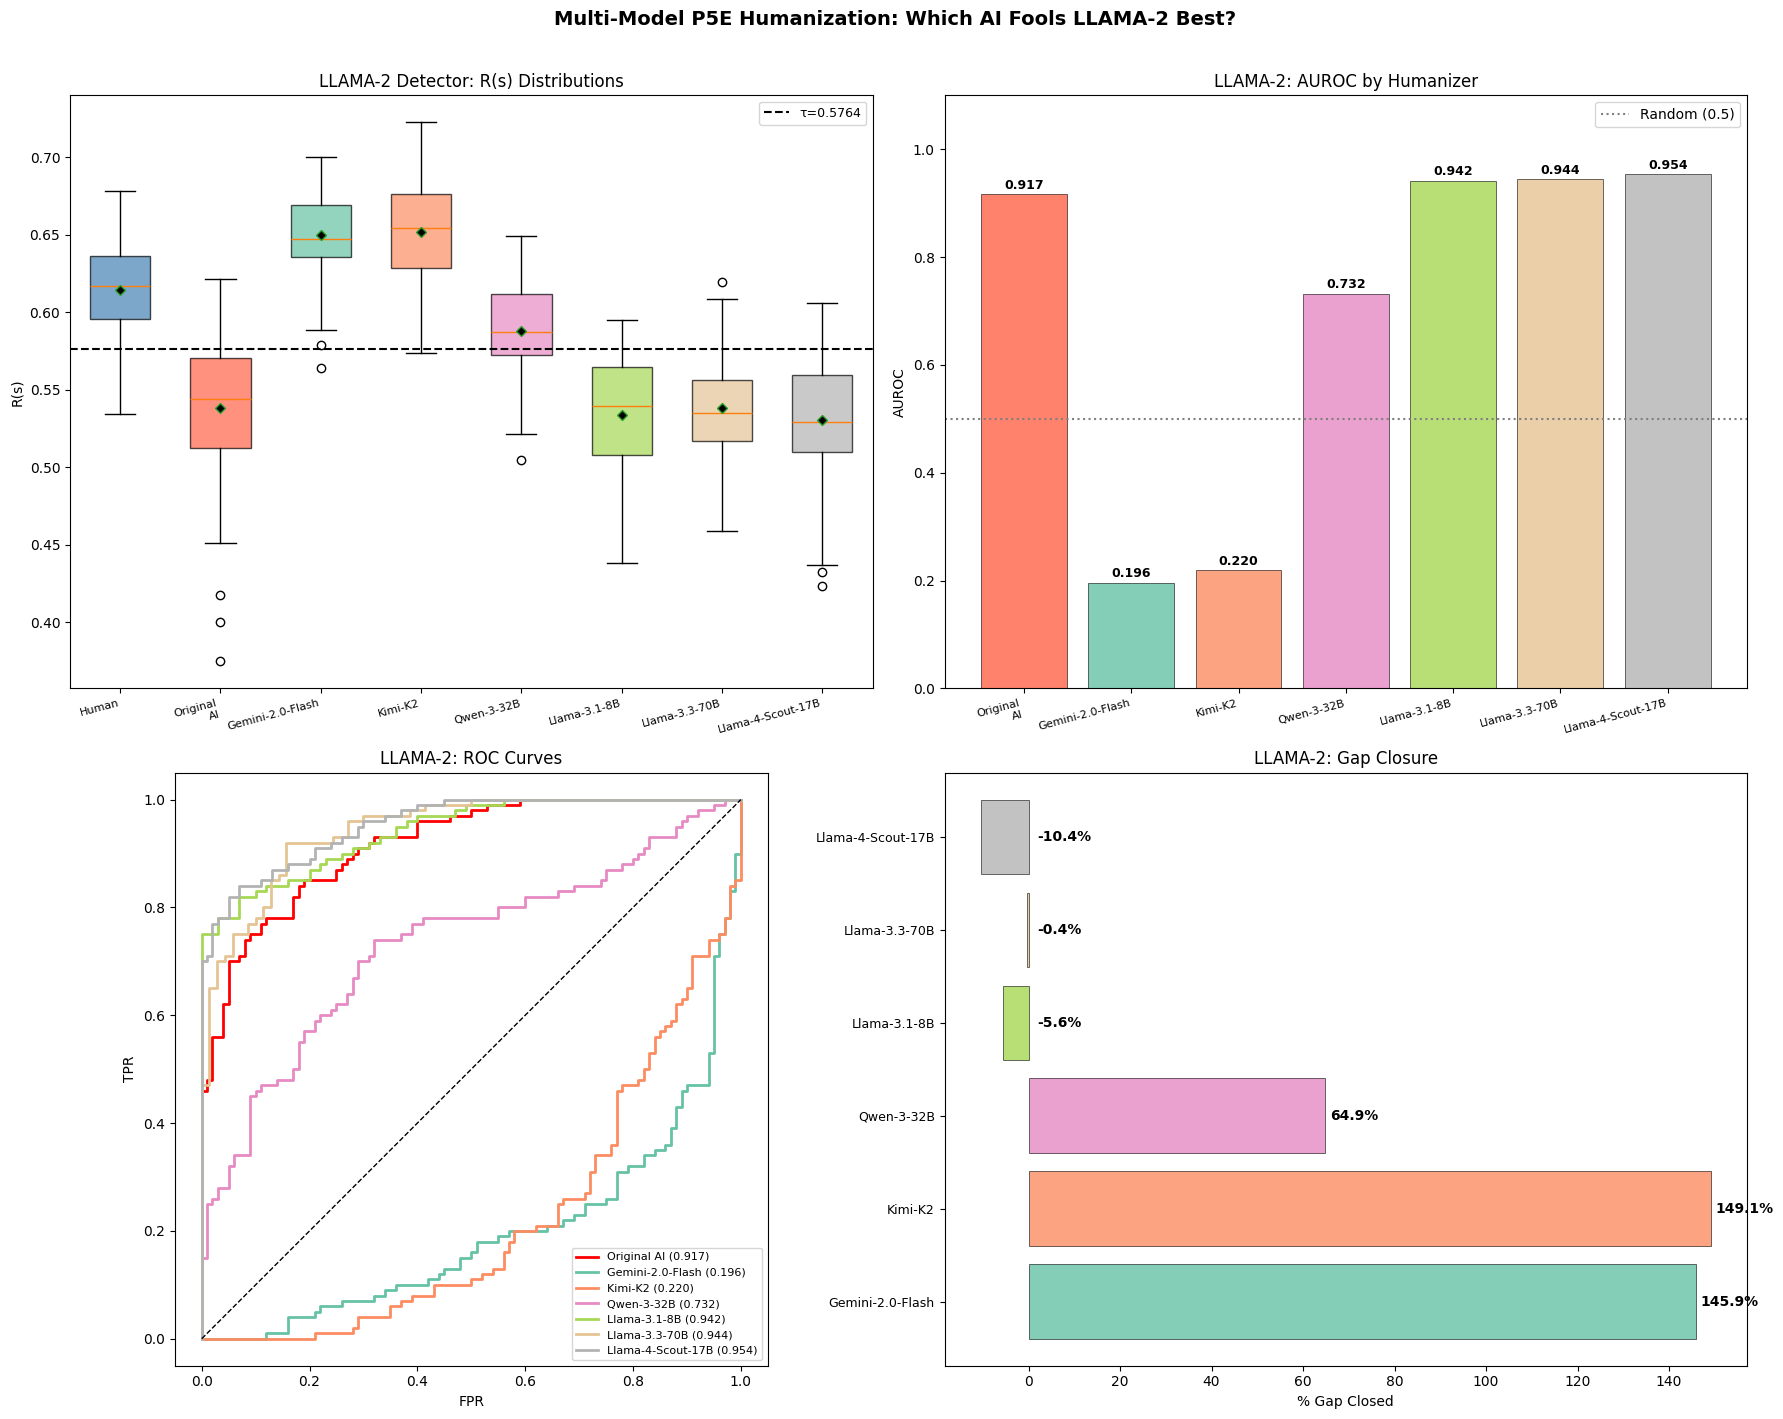

In [8]:
# === PLOTS ===
n_models = len(ranked)
colors = plt.cm.Set2(np.linspace(0, 1, n_models))
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

bp = axes[0,0].boxplot([hv, av] + [r['scores'] for _, r in ranked], patch_artist=True, widths=0.6, showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='black', markersize=5))
for patch, c in zip(bp['boxes'], ['steelblue', 'tomato'] + list(colors)):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[0,0].set_xticklabels(['Human', 'Original\nAI'] + [r['label'].replace(' ', '\n', 1) for _, r in ranked], fontsize=8, rotation=15, ha='right')
axes[0,0].axhline(GMM, color='black', ls='--', lw=1.5, label=f'τ={GMM:.4f}')
axes[0,0].set_ylabel('R(s)'); axes[0,0].set_title('LLAMA-2 Detector: R(s) Distributions'); axes[0,0].legend(fontsize=9)

aurocs = [auroc_ai] + [r['auroc'] for _, r in ranked]
bars = axes[0,1].bar(range(len(aurocs)), aurocs, color=['tomato'] + list(colors), alpha=0.8, edgecolor='black', linewidth=0.5)
for i, v in enumerate(aurocs): axes[0,1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[0,1].set_xticks(range(len(aurocs)))
axes[0,1].set_xticklabels(['Original\nAI'] + [r['label'] for _, r in ranked], fontsize=8, rotation=15, ha='right')
axes[0,1].axhline(0.5, color='gray', ls=':', label='Random (0.5)')
axes[0,1].set_ylabel('AUROC'); axes[0,1].set_title('LLAMA-2: AUROC by Humanizer'); axes[0,1].legend(); axes[0,1].set_ylim(0, 1.1)

fpr_ai, tpr_ai, _ = roc_curve([1]*len(hv)+[0]*len(av), hv+av)
axes[1,0].plot(fpr_ai, tpr_ai, 'r-', lw=2, label=f'Original AI ({auroc_ai:.3f})')
for (mk, r), c in zip(ranked, colors):
    fpr, tpr, _ = roc_curve([1]*len(hv)+[0]*len(r['scores']), hv+r['scores'])
    axes[1,0].plot(fpr, tpr, color=c, lw=2, label=f'{r["label"]} ({r["auroc"]:.3f})')
axes[1,0].plot([0,1],[0,1],'k--',lw=1)
axes[1,0].set_xlabel('FPR'); axes[1,0].set_ylabel('TPR'); axes[1,0].set_title('LLAMA-2: ROC Curves')
axes[1,0].legend(fontsize=8); axes[1,0].set_aspect('equal')

gap_vals = [r['gap_closed'] for _, r in ranked]
axes[1,1].barh(range(n_models), gap_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
for i, v in enumerate(gap_vals): axes[1,1].text(max(v+1, 2), i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[1,1].set_yticks(range(n_models)); axes[1,1].set_yticklabels([r['label'] for _, r in ranked], fontsize=9)
axes[1,1].set_xlabel('% Gap Closed'); axes[1,1].set_title('LLAMA-2: Gap Closure')

plt.suptitle('Multi-Model P5E Humanization: Which AI Fools LLAMA-2 Best?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('llama2_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

In [9]:
# === SAVE RESULTS ===
output = {
    'experiment': 'Multi-Model P5E Humanization — LLAMA-2 Detector',
    'prompt': 'P5E_enhanced_lexicon',
    'source_model': 'GPT-4 Turbo',
    'detector': 'Mistral-7B (observer) + Mistral-7B-Instruct (performer)',
    'observer_model': 'meta-llama/Llama-2-7b-hf',
    'performer_model': 'meta-llama/Llama-2-7b-chat-hf',
    'n_texts': N,
    'threshold': float(GMM),
    'human': {'mean': float(hm), 'std': float(np.std(hv)), 'n': len(hv)},
    'original_ai': {'mean': float(am), 'std': float(np.std(av)), 'n': len(av), 'auroc': float(auroc_ai)},
    'humanizer_models': {}
}
for mk, r in results.items():
    output['humanizer_models'][mk] = {
        'label': r['label'], 'mean': float(r['mean']),
        'std': float(np.std(r['scores'])), 'n': r['n'],
        'auroc': float(r['auroc']), 'gap_closed': float(r['gap_closed']),
        'evade_rate': float(r['evade_rate']),
    }
output['all_scores'] = {k: [float(s) if s == s else None for s in v] for k, v in all_scores.items()}

with open('llama2_results.json', 'w') as f:
    json.dump(output, f, indent=2)
print('Saved llama2_results.json')

print(f'\n{"="*60}')
print('LLAMA-2 DETECTOR SUMMARY')
print(f'{"="*60}')
best_mk, best_r = ranked[0]
print(f'Best humanizer vs Mistral: {best_r["label"]}')
print(f'  AUROC: {best_r["auroc"]:.4f} (vs Original AI: {auroc_ai:.4f})')
print(f'  Gap closed: {best_r["gap_closed"]:.1f}%')
print(f'  Evasion rate: {best_r["evade_rate"]:.1f}%')

Saved llama2_results.json

LLAMA-2 DETECTOR SUMMARY
Best humanizer vs Mistral: Gemini-2.0-Flash
  AUROC: 0.1961 (vs Original AI: 0.9170)
  Gap closed: 145.9%
  Evasion rate: 99.0%
